In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# set random seed for reproducibility
np.random.seed(0)

# set solve_ivp keyword arguments
solve_ivp_kwargs = {}
solve_ivp_kwargs['method'] = 'RK45'
solve_ivp_kwargs['rtol'] = 1e-6
solve_ivp_kwargs['atol'] = 1e-6

A comment on data formatting:
- data arrays should take the form $[x(t_1), x(t_2), ..., x(t_n)]$
- thus, arrays should have the form (rows, cols) == (n_state_vars, n_samples)
    - so, x[0] should be many samples of the first state variable
    - note the syntax "np.array([row1, row2, ...])"

In [2]:
# generate Lotka-Volterra right-hand side functions
def generate_lotka_volterra_rhs(a, b, c, d):
    def lotka_volterra_rhs(t, x):
        # we expect x to be a 2D array with shape (rows, cols) == (2, n_samples)
        assert x.shape[0] == 2
        return np.array([a*x[0] - b*x[0]*x[1], -c*x[1] + d*x[0]*x[1]])
    return lotka_volterra_rhs

# make a specific Lotka-Volterra right-hand side function
lotka_volterra_rhs = generate_lotka_volterra_rhs(1, 0.1, 1.5, 0.75)

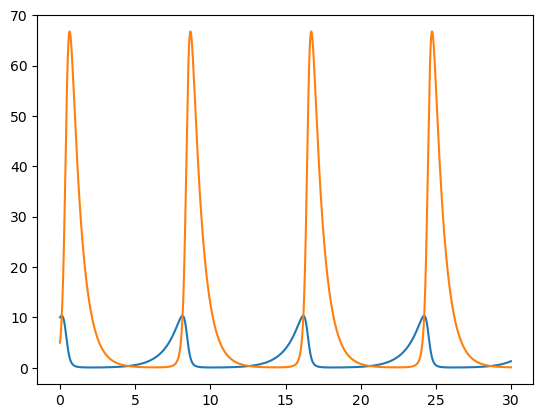

In [3]:
# generate general training data
def generate_training_data(rhs, t_span, dt, x0):
    t_train = np.arange(t_span[0], t_span[1], dt)
    x_train = solve_ivp(rhs, t_span, x0, t_eval=t_train, **solve_ivp_kwargs).y
    # NOTE: x_train.shape == (n_samples, n_state_vars) == (rows, cols)
    return t_train, x_train

dt = 0.01
t_span_train = (0, 30)
x0_train = (10, 5)
t_train, x_train = generate_training_data(lotka_volterra_rhs, t_span=t_span_train, dt=dt, x0=x0_train)

plt.plot(t_train, x_train.T)

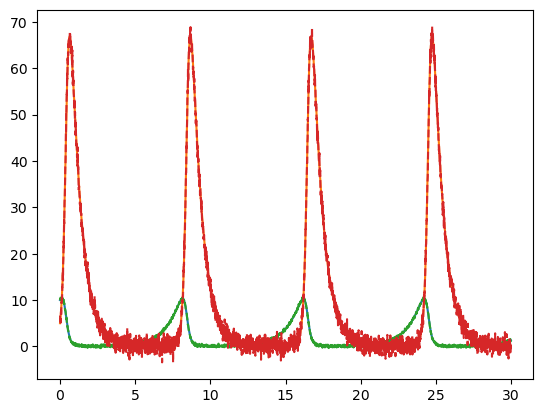

In [16]:
def generate_noisy_data(x, noise_level):
    # set random seed for reproducibility
    np.random.seed(0)

    # calculate the root-mean-square (RMS) value of each state variable
    rms = np.sqrt(np.mean(x**2, axis=1)).reshape((-1, 1))
    
    # calculate the standard deviation of the noise to add
    std = rms * noise_level

    # generate appropriate noise by scaling samples from a standard normal
    # NOTE: because "std" is a vector it gets broadcast to the shape of the standard normal noise
    noise = std * np.random.standard_normal(x.shape)
    
    return x + noise


x_train_noisy = generate_noisy_data(x_train, 0.05)
plt.plot(t_train, x_train.T)
plt.plot(t_train, x_train_noisy.T, '--')

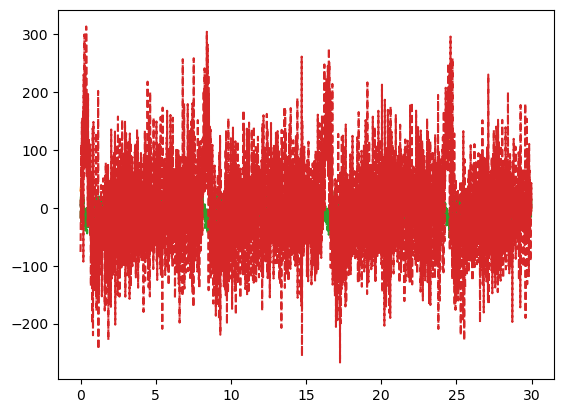

In [17]:
from derivative import dxdt

# generate the true derivative
x_dot_true = lotka_volterra_rhs(t_train, x_train)

# x_dot_approx = dxdt(x_train_noisy, t_train, kind="savitzky_golay", left=.5, right=.5, order=3)
x_dot_approx = dxdt(x_train_noisy, t_train, kind="finite_difference", k=1)

plt.plot(t_train, x_dot_true.T)
plt.plot(t_train, x_dot_approx.T, '--')

In [18]:
import pysindy as ps
from tqdm import tqdm

poly_order = 5
threshold = 0.02 # NOTE: was 0.5 in demo notebook

noise_levels = [0, 1e-4, 1e-3, 1e-2, 1e-1, 1]

models = []
for noise_level in tqdm(noise_levels):
    # generate noisy data
    x_train_noisy = generate_noisy_data(x_train, noise_level)
    
    # generate the derivative of the noisy data
    # NOTE: we can change the kind of derivative and the parameters of the derivative method!
    x_dot_approx = dxdt(x_train_noisy, t_train, kind="finite_difference", k=1)

    # create a SINDy model
    model = ps.SINDy(
        optimizer=ps.STLSQ(threshold=threshold),
        feature_library=ps.PolynomialLibrary(degree=poly_order),
    )

    # fit the SINDy model
    model.fit(x_train_noisy.T, t=t_train, x_dot=x_dot_approx.T)

    # append the model to the list of models
    models.append(model)


# print the models
for i in range(len(noise_levels)):
    print(f"noise level: {noise_levels[i]}")
    models[i].print(lhs=["x", "y"])
    print()

100%|██████████| 6/6 [00:01<00:00,  4.12it/s]

noise level: 0
x = 1.000 x0 + -0.100 x0 x1
y = -15.298 1 + 9.213 x0 + -0.040 x1 + -0.111 x0^2

noise level: 0.0001
x = 1.000 x0 + -0.100 x0 x1
y = -1.500 x1 + 0.750 x0 x1

noise level: 0.001
x = 0.999 x0 + -0.100 x0 x1
y = -1.500 x1 + 0.750 x0 x1

noise level: 0.01
x = 0.998 x0 + -0.100 x0 x1
y = -1.499 x1 + 0.750 x0 x1

noise level: 0.1
x = 0.093 1 + -0.363 x0 + 0.022 x0^2
y = -0.184 1 + -1.423 x0 + -1.426 x1 + 0.616 x0^2 + 0.718 x0 x1 + -0.049 x0^3

noise level: 1
x = 0.666 1 + -0.432 x0 + -0.111 x1 + 0.034 x0^2
y = -16.387 1 + 10.195 x0 + 0.402 x0^2 + -0.272 x0 x1 + -0.101 x0^3 + 0.036 x0^2 x1



In [51]:
def generate_model_prediction(model, t_span, dt, x0):
    def model_rhs(t, x):
        return model.predict(x.reshape((1, -1))).reshape(-1)
    
    t_pred = np.arange(t_span[0], t_span[1], dt)
    ivp_result = solve_ivp(model_rhs, t_span, x0, t_eval=t_pred, **solve_ivp_kwargs)

    return t_pred, ivp_result.y, ivp_result.success

dt = 0.01
t_span_eval = (0, 30)
x0_eval = (10, 5)

t_preds = []
x_preds = []
for model in tqdm(models):
    t_pred, x_pred, success = generate_model_prediction(model, t_span=t_span_eval, dt=dt, x0=x0_eval)
    t_preds.append(t_pred)
    x_preds.append(x_pred)

100%|██████████| 7/7 [00:13<00:00,  1.88s/it]


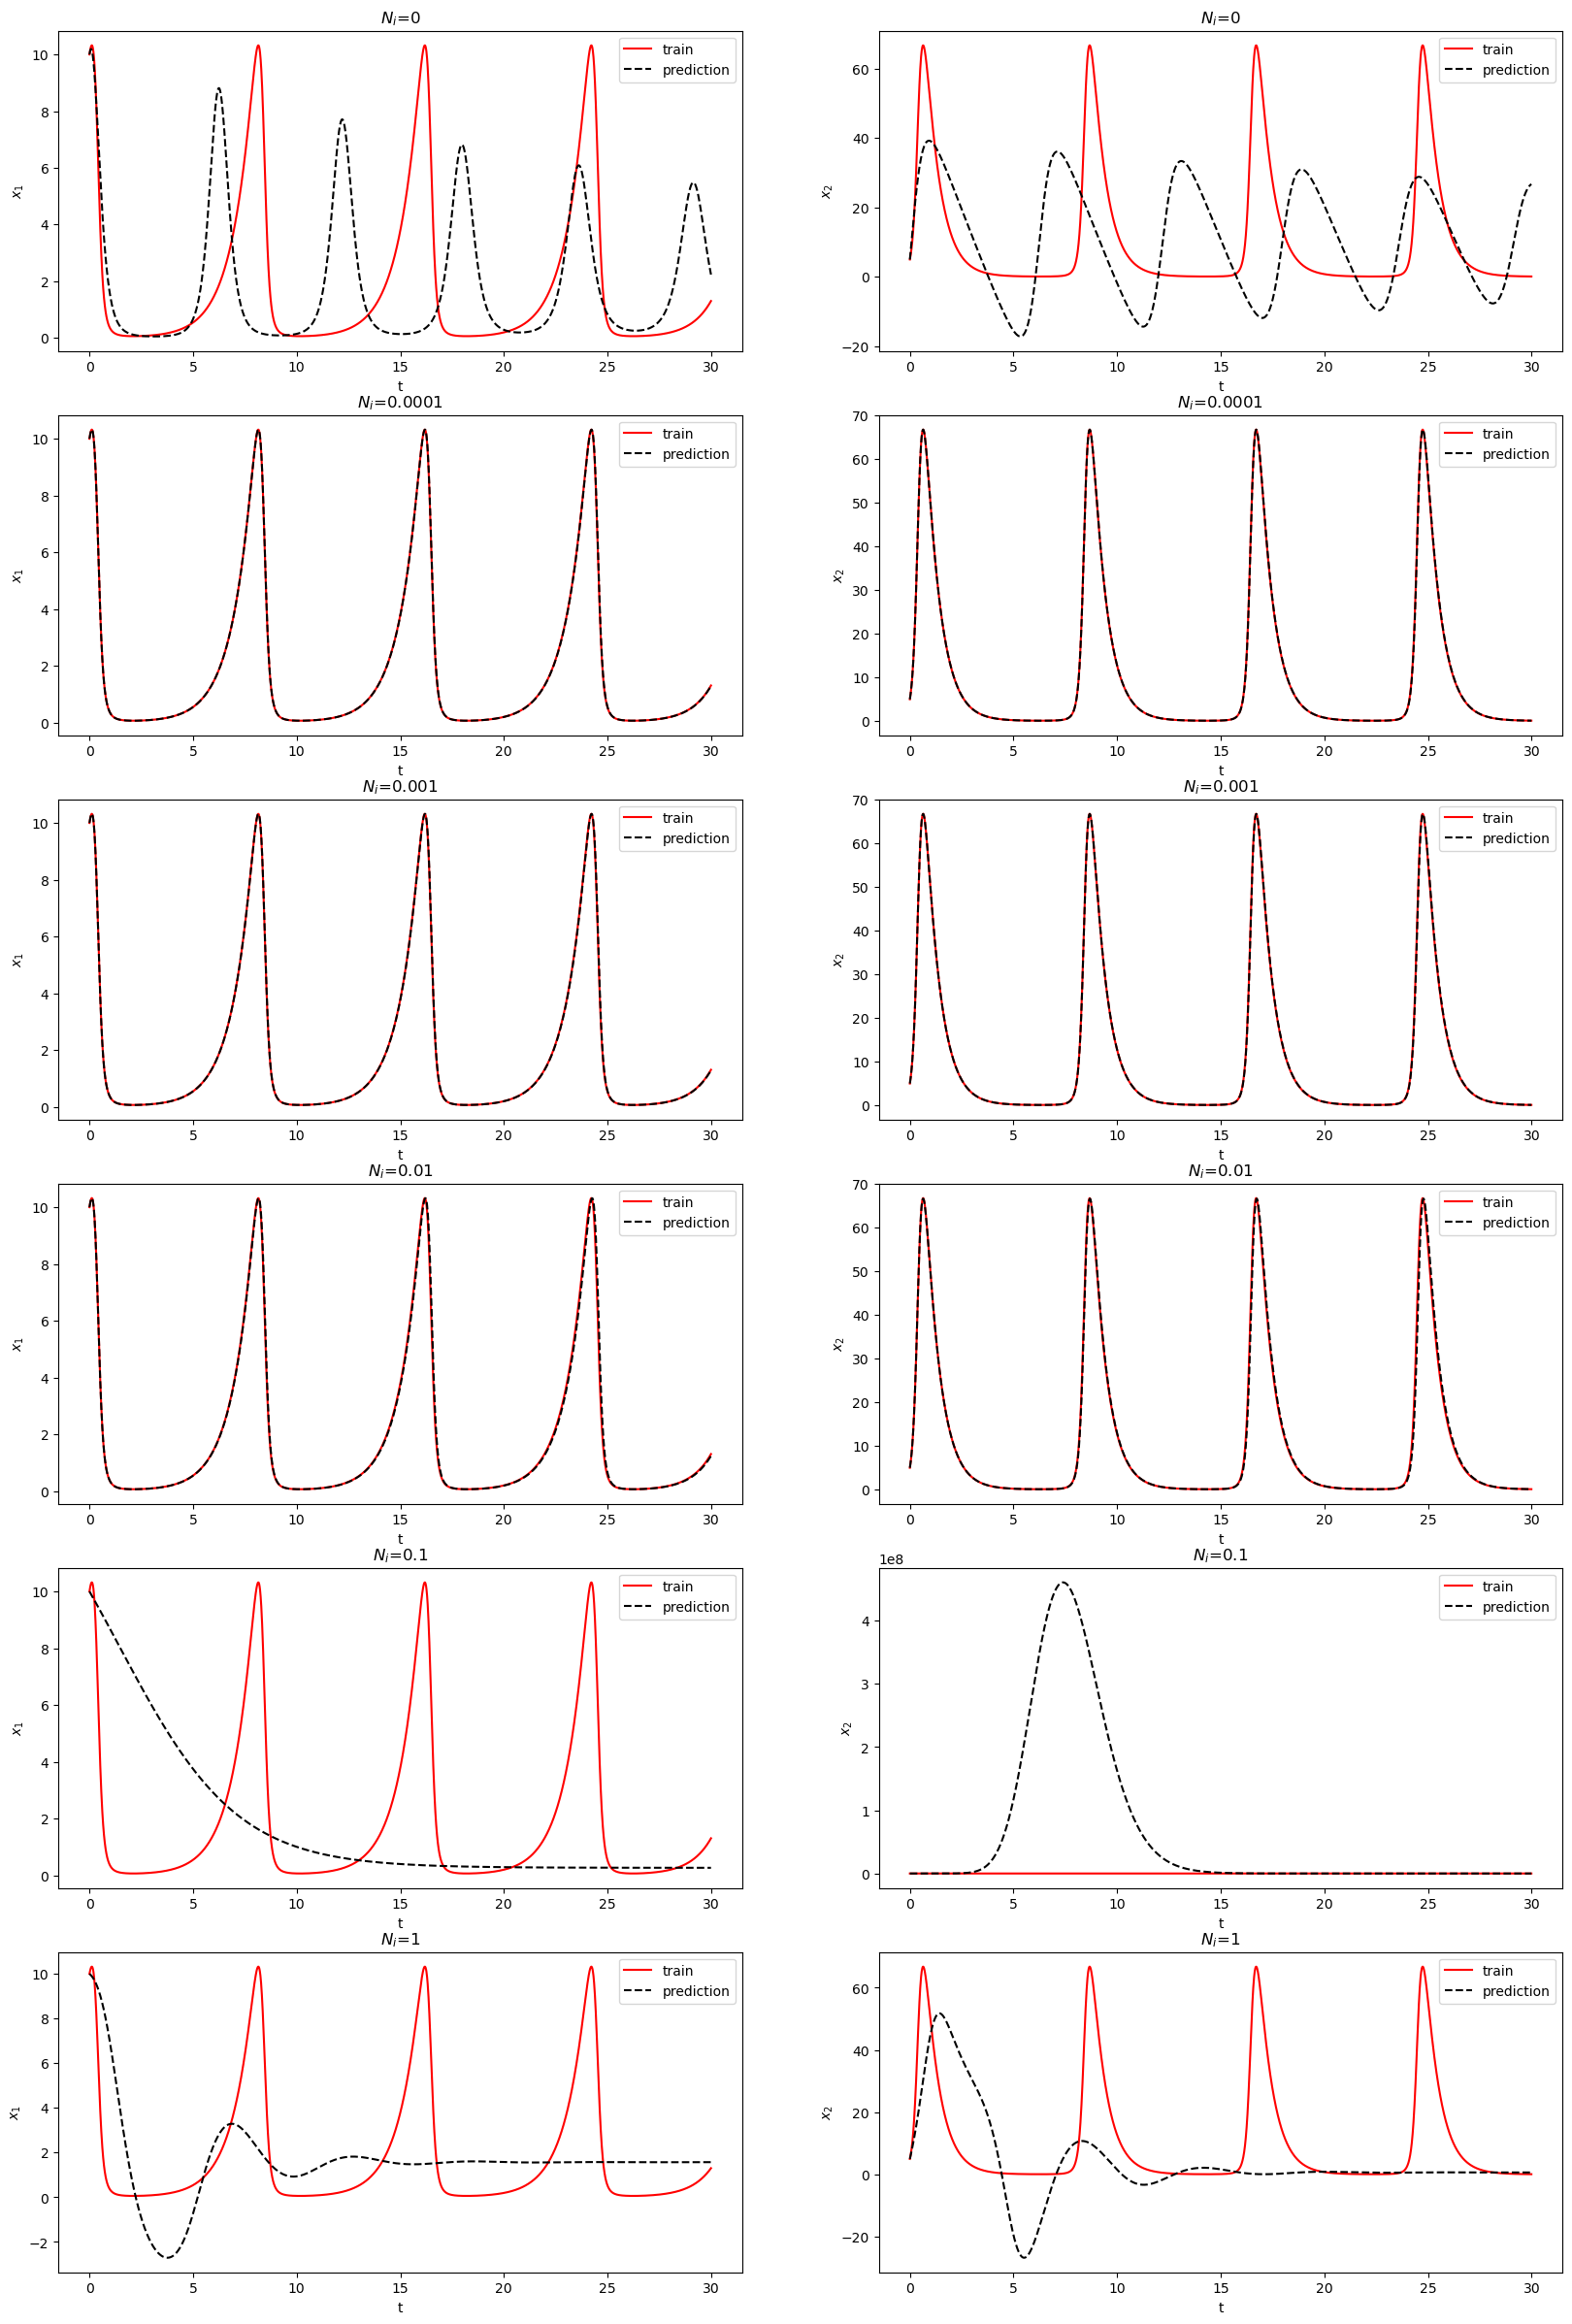

In [31]:
n_rows = len(noise_levels)
n_cols = 2

fig, axs = plt.subplots(n_rows, n_cols, figsize=(10*n_cols, 5*n_rows))

for row in range(n_rows):
    # each row corresponds to a different noise level

    for col in range(n_cols):
        # plot the col'th training state variable
        axs[row, col].plot(t_train, x_train[col], "r", label="train")
        
        # plot the col'th state variable model prediction
        axs[row, col].plot(t_preds[row], x_preds[row][col], "k--", label="prediction")

        # set the title and labels
        axs[row, col].set_title(f"$N_i$={noise_levels[row]}")
        axs[row, col].set_xlabel("t")
        axs[row, col].set_ylabel(f"$x_{col + 1}$")
        axs[row, col].legend()

fig.show()

In [35]:
def relative_trajectory_error(x_true, x_pred):
    # calculate the relative error between the true and predicted trajectories using the frobenius norm
    assert x_true.shape == x_pred.shape
    return np.sum((x_true - x_pred)**2) / np.sum(x_true**2)


for i in range(len(noise_levels)):
    rte = relative_trajectory_error(x_train, x_preds[i])
    print(f"noise level: {noise_levels[i]:.6f}, relative trajectory error: {rte:.6f}")

noise level: 0.000000, relative trajectory error: 1.060815
noise level: 0.000100, relative trajectory error: 0.000103
noise level: 0.001000, relative trajectory error: 0.000158
noise level: 0.010000, relative trajectory error: 0.002098
noise level: 0.100000, relative trajectory error: 45486529048040.109375
noise level: 1.000000, relative trajectory error: 0.929097


##### TODO: write some code to make it easy to compare coefficients

In [52]:
t_span_train = t_span_eval = (0, 30)
x0_train = x0_eval = (10, 5)

poly_order = 5
threshold = 0.02 # NOTE: was 0.5 in demo notebook
# noise_levels = [0, 1e-4, 1e-3, 1e-2, 1e-1, 1]
noise_level = 0.01

# dts = np.linspace(0.01, 1, 10)
dts = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]

t_trains = []
x_trains = []
models = []
t_preds = []
x_preds = []
for dt in tqdm(dts):
    t_train, x_train = generate_training_data(lotka_volterra_rhs, t_span=t_span_train, dt=dt, x0=x0_train)
    t_trains.append(t_train)
    x_trains.append(x_train)
    
    # generate noisy data
    x_train_noisy = generate_noisy_data(x_train, noise_level)
    # generate the derivative of the noisy data
    x_dot_approx = dxdt(x_train_noisy, t_train, kind="finite_difference", k=1)
    # create a SINDy model
    model = ps.SINDy(
        optimizer=ps.STLSQ(threshold=threshold),
        feature_library=ps.PolynomialLibrary(degree=poly_order),
    )
    # fit the SINDy model
    model.fit(x_train_noisy.T, t=t_train, x_dot=x_dot_approx.T)
    models.append(model)
    
    t_pred, x_pred, sucess = generate_model_prediction(model, t_span=t_span_eval, dt=dt, x0=x0_eval)
    if not sucess:
        print(f"failed to generate model prediction with dt={dt}")
        t_preds.append(None)
        x_preds.append(None)
    else:
        t_preds.append(t_pred)
        x_preds.append(x_pred)


# print the models
for i in range(len(dts)):
    print(f"dt: {dts[i]}")
    models[i].print(lhs=["x", "y"])
    print()

 43%|████▎     | 3/7 [00:07<00:10,  2.69s/it]

failed to generate model prediction with dt=0.05


100%|██████████| 7/7 [00:13<00:00,  1.91s/it]

dt: 0.01
x = 0.998 x0 + -0.100 x0 x1
y = -1.499 x1 + 0.750 x0 x1

dt: 0.02
x = 0.995 x0 + -0.100 x0 x1
y = -1.496 x1 + 0.748 x0 x1

dt: 0.05
x = 1.973 1 + -0.100 x0 + -0.195 x1
y = -0.122 x0 + -1.474 x1 + 0.029 x0^2 + 0.737 x0 x1

dt: 0.1
x = 0.956 x0 + -0.097 x0 x1
y = -1.024 1 + 2.139 x0 + -1.430 x1 + -0.670 x0^2 + 0.712 x0 x1 + 0.053 x0^3

dt: 0.2
x = 1.742 1 + 0.191 x0 + -0.188 x1 + -0.034 x0^2
y = -1.766 1 + 4.697 x0 + -1.408 x1 + -1.779 x0^2 + 0.808 x0 x1 + 0.160 x0^3 + -0.025 x0^2 x1

dt: 0.5
x = -0.174 1 + -0.207 x0 + 0.592 x0^2 + -0.055 x0 x1 + -0.060 x0^3
y = 0.732 1 + -6.496 x0 + -1.945 x1 + 4.278 x0^2 + 6.092 x0 x1 + -0.823 x0^3 + -0.881 x0^2 x1 + -0.044 x0 x1^2 + 0.045 x0^4 + 0.052 x0^3 x1

dt: 1
x = -0.080 1 + 1.488 x0 + -0.096 x0^2 + -0.248 x0 x1
y = 0.505 1 + 0.562 x0 + -2.699 x1 + -2.161 x0 x1 + 0.073 x1^2 + -0.035 x0^2 x1 + 0.044 x0^3 x1 + -0.020 x0^2 x1^2



In [54]:
for i in range(len(dts)):
    if t_preds[i] is None:
        print(f"dt: {dts[i]:.6f}, failed to generate model prediction")
        continue
    rte = relative_trajectory_error(x_trains[i], x_preds[i])
    print(f"dt: {dts[i]:.6f}, relative trajectory error: {rte:.6f}")

dt: 0.010000, relative trajectory error: 0.002098
dt: 0.020000, relative trajectory error: 0.012687
dt: 0.050000, failed to generate model prediction
dt: 0.100000, relative trajectory error: 0.558453
dt: 0.200000, relative trajectory error: 30.811809
dt: 0.500000, relative trajectory error: 0.774699
dt: 1.000000, relative trajectory error: 0.972001


<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:22: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Elliot\AppData\Local\Temp\ipykernel_41248\665350440.py:22: SyntaxWarning: invalid escape sequence '\D'
  axs[row, col].set_title(f"$\Delta t$={dts[row]}")


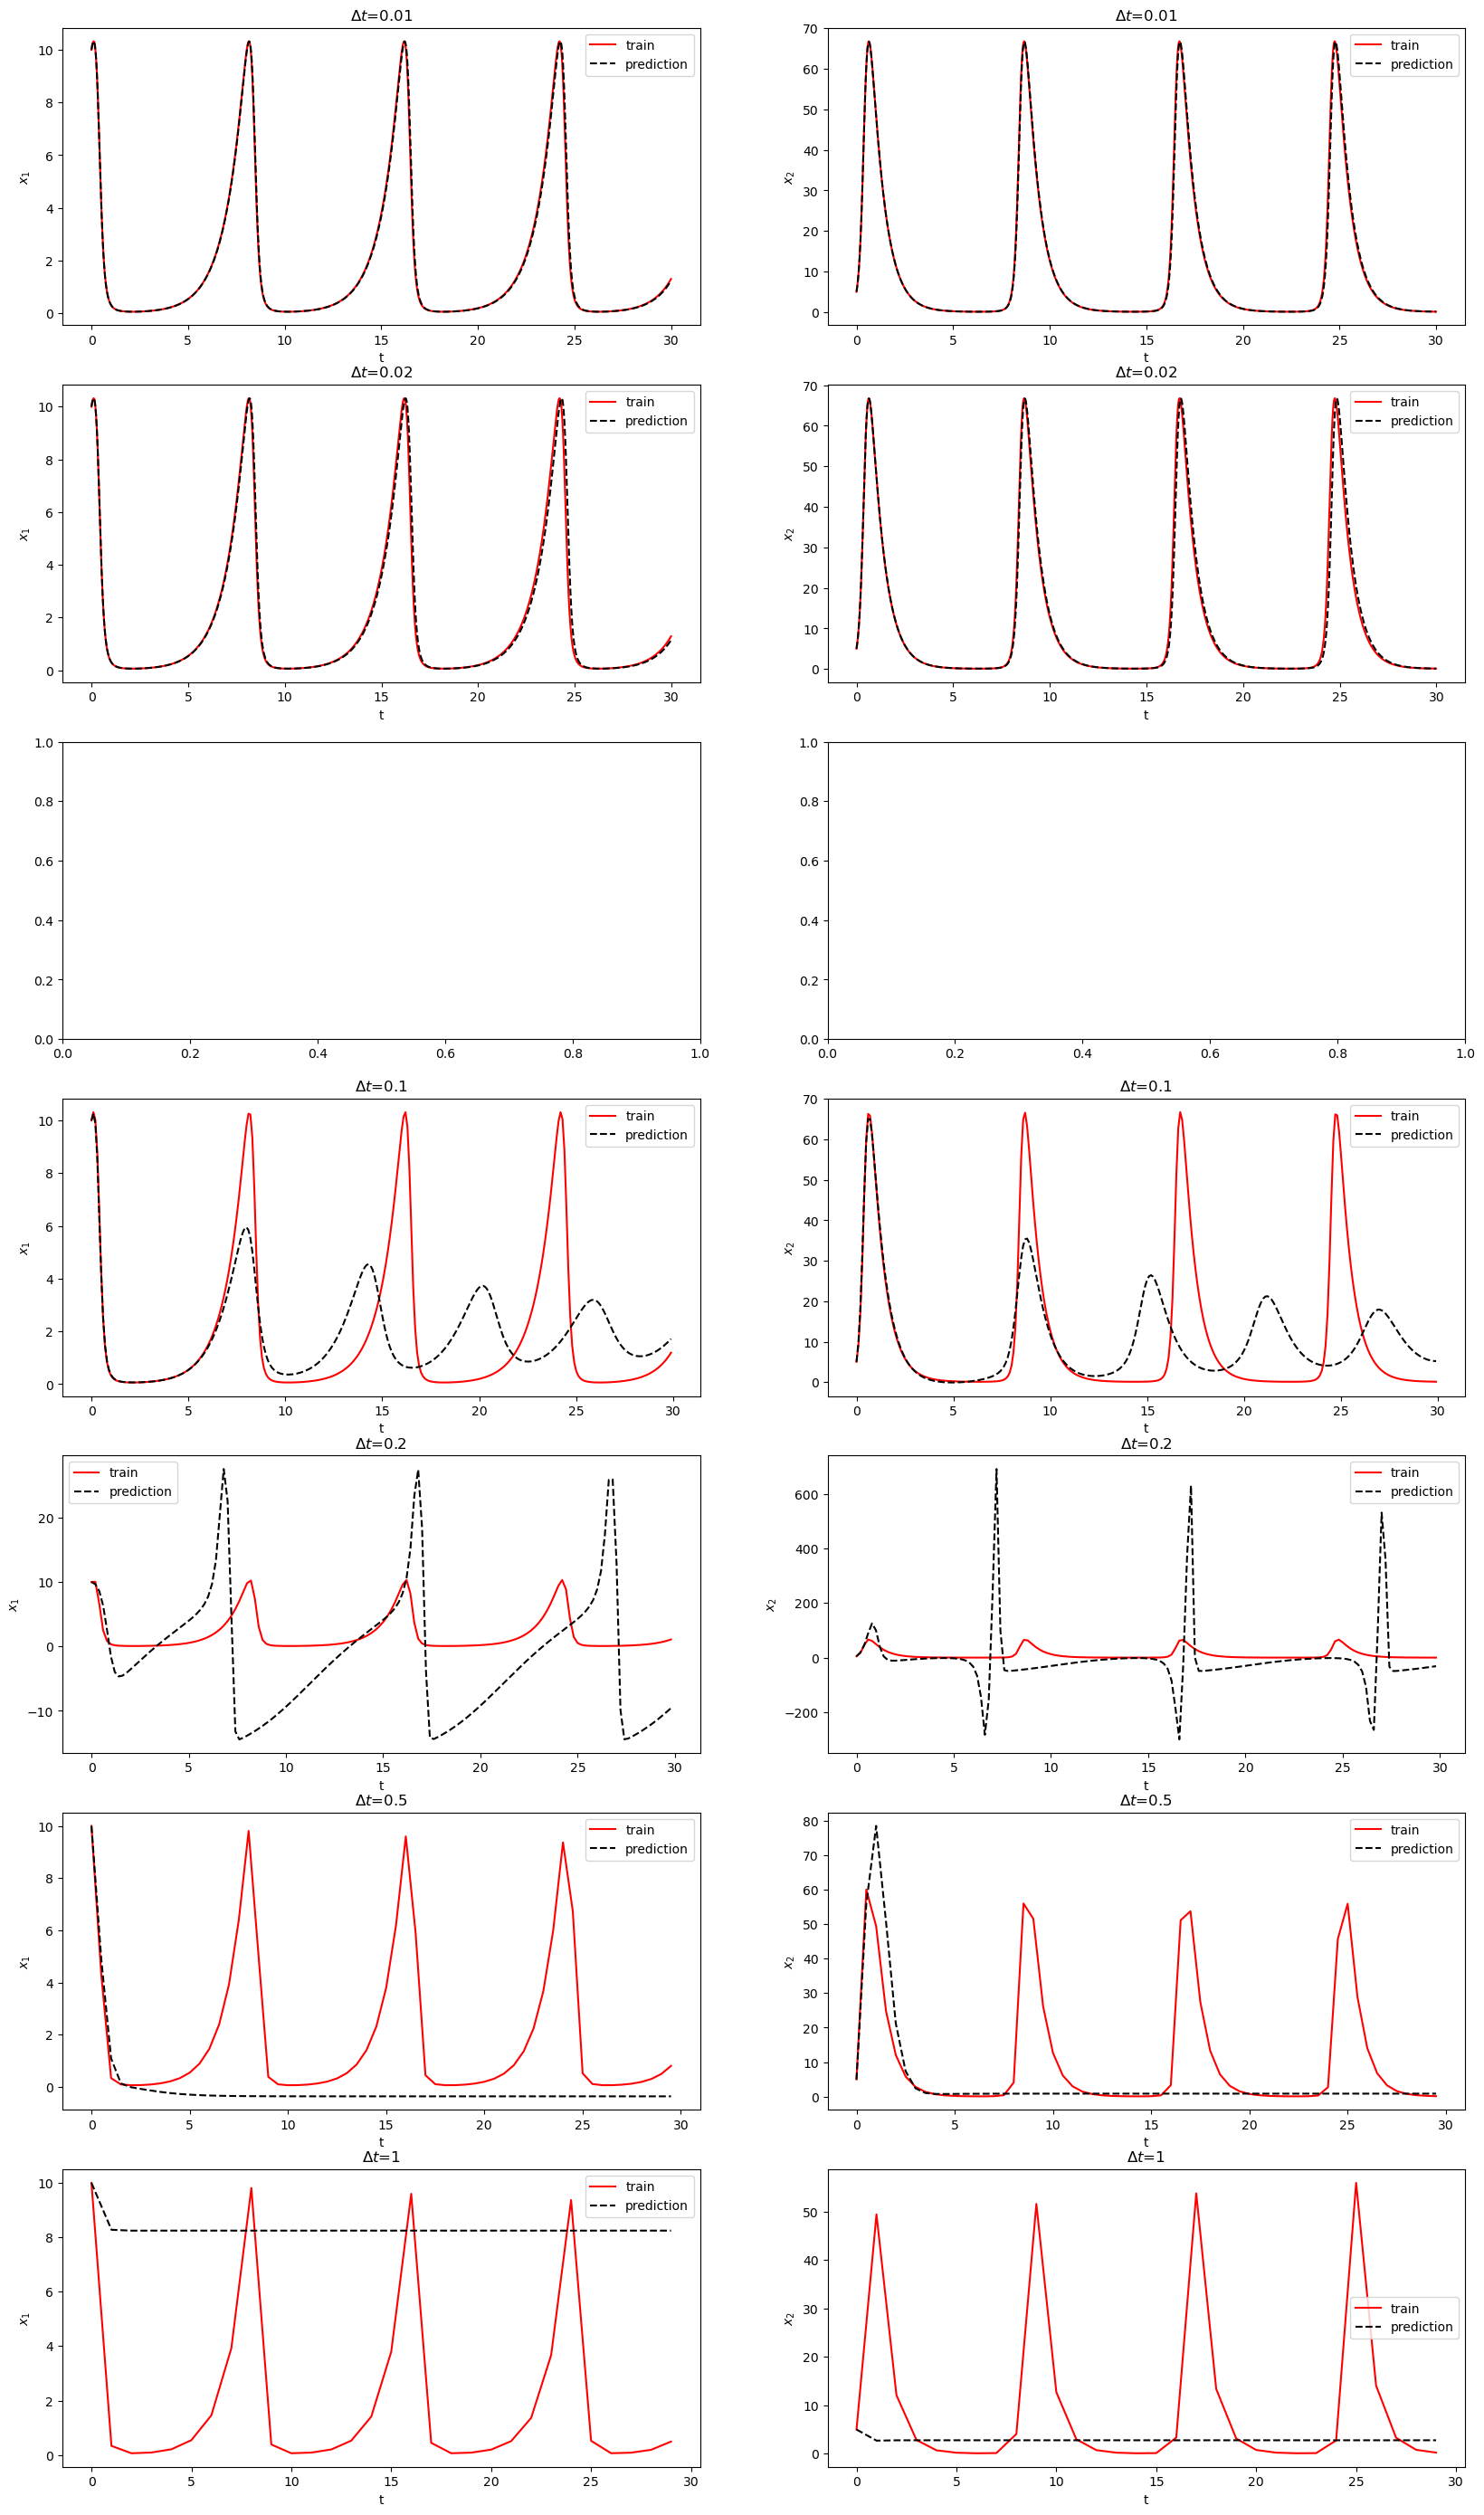

In [57]:
# plot the results
n_rows = len(dts)
n_cols = 2

fig, axs = plt.subplots(n_rows, n_cols, figsize=(10*n_cols, 5*n_rows))

for row in range(n_rows):
    # each row corresponds to a different noise level

    # skip if the model prediction failed
    if t_preds[row] is None:
        continue

    for col in range(n_cols):
        # plot the col'th training state variable
        axs[row, col].plot(t_trains[row], x_trains[row][col], "r", label="train")
        
        # plot the col'th state variable model prediction
        axs[row, col].plot(t_preds[row], x_preds[row][col], "k--", label="prediction")

        # set the title and labels
        axs[row, col].set_title(f"$\Delta t$={dts[row]}")
        axs[row, col].set_xlabel("t")
        axs[row, col].set_ylabel(f"$x_{col + 1}$")
        axs[row, col].legend()